<img src="../../figs/holberton_logo.png" alt="logo" width="500"/>

# CIFAR-10 Feed-Forward Neural Network 

## Executive Summary

The **CIFAR-10** dataset is a widely used benchmark for image classification tasks. It consists of `60,000` `32x32` color images in `10` classes, with `6,000` images per class. **The classes include airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships, and trucks**. 

The images are low-resolution and can be challenging to classify due to their small size and variability in appearance. The dataset is commonly used to evaluate the performance of image classification algorithms, including deep learning models.

## Setting up: Loading CIFAR-10

The `CIFAR-10` dataset consists of `60,000 32x32` **color** images in `10` classes, with `6,000` images per class. The dataset is split into two subsets: 
- a training set of `50,000` images
- a testing set of `10,000` images


In [1]:
import keras
from keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

# Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

print(x_train_full.shape, x_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


## Normalize Data and Add Validation Set

Next, we normalize the pixel values of CIFAR-10 images in both the training and test sets to a range between `0` and `1`. 

To increase the robustness of our model, we also split the training set into `x_train` and `y_train` for model training and `x_valid` and `y_valid` for validation, with the last `5000` samples reserved for validation

In [2]:
# Normalize the data
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Split the training set into training and validation sets
x_train, x_valid = x_train_full[:-5000], x_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Print the shapes of the training, validation, and test sets
print("Training set shape:", x_train.shape)
print("Validation set shape:", x_valid.shape)
print("Test set shape:", x_test.shape)
print(y_train.shape)
print(y_valid.shape)



Training set shape: (45000, 32, 32, 3)
Validation set shape: (5000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
(45000, 1)
(5000, 1)


## Visualizing the dataset

The Cifar-10 dataset contains `10` classes, each corresponding to a different article of clothing:

| Label | Class Category |
|-------|----------------|
| 0     | airplane       |
| 1     | automobile     |
| 2     | bird           |
| 3     | cat            |
| 4     | deer           |
| 5     | dog            |
| 6     | frog           |
| 7     | horse          |
| 8     | ship           |
| 9     | truck          |

These classes can be **challenging to classify** due to several factors, including 

- the variability in appearance within each class 

- the presence of similar-looking objects across different classes

- variations in orientation, lighting conditions, and background clutter

- relatively low resolution (32x32 pixels) 



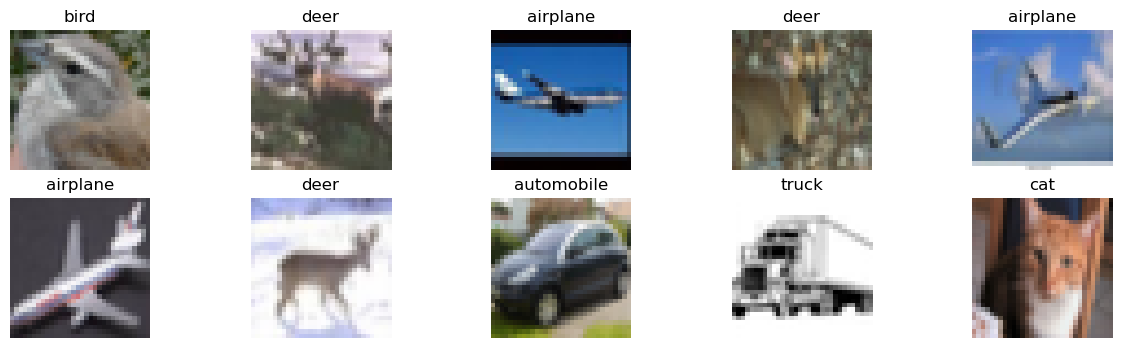

In [3]:
# Define the class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Visualize random images from the dataset
plt.figure(figsize=(15, 4))
for i in range(10):
    idx = np.random.randint(0, len(x_train))
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[idx])
    plt.title(class_names[y_train[idx][0]])
    plt.axis('off')
plt.show()

## Building the Convolutional Neural Network

### Architecture of the Neural Network

The architecture of a feedforward neural network typically consists of an input layer, one or more hidden layers, and an output layer. The input layer should have the same number of nodes as the number of input features in the data, while the output layer should have the same number of nodes as the number of classes in the data. The number of hidden layers and the number of nodes in each hidden layer can be adjusted based on the complexity of the problem and the size of the dataset

- **Number of layers**: Three layers is a reasonable starting point for a feedforward neural network. Adding more layers can potentially improve performance, but can also increase the risk of overfitting. We can always experiment with adding or removing layers to find the optimal configuration for this particular task.

- **Number of neurons per layer**: The number of neurons per layer is also a hyperparameter that can be tuned for optimal performance. A good heuristic is to start with more neurons in the first layer, and gradually decrease the number of neurons in subsequent layers. 

### Activation Functions

Activation functions are used to introduce nonlinearity into the neural network, allowing it to learn more complex patterns in the data. Common activation functions include `ReLU`, `sigmoid`, and `tanh`.

- `ReLU` is a popular choice for activation function in deep learning due to its simplicity and effectiveness. It helps the network to converge faster during training and is less prone to the vanishing gradient problem. For the output layer, we used softmax, which is appropriate for multi-class classification tasks like CIFAR-10.

### Architecture

- Input Layer: Accepts `32x32` RGB images (3D tensors).
- Flattening Layer: Converts `3D` image tensors into `1D` arrays.
- Hidden Layers: Dense (fully connected) layers capture complex patterns in the data.
- Output Layer: Produces class probabilities for `10` CIFAR-10 classes using softmax activation.

In [ ]:
"""
# Define the CNN architecture
model = models.Sequential([
    # Convolutional layer 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), padding='same'),  # Use 'same' padding
    layers.Dropout(0.25),

    # Convolutional layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), padding='same'),  # Use 'same' padding
    layers.Dropout(0.25),

    # Convolutional layer 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), padding='same'),  # Use 'same' padding
    layers.Dropout(0.25),

    # Flatten the output for dense layers
    layers.Flatten(),

    # Dense fully connected layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Output layer
    layers.Dense(10, activation='softmax')
])
"""

from keras import models, layers

# intializer
initializer = keras.initializers.HeNormal()

model = models.Sequential([
    layers.Conv2D(filters=6,
                  kernel_size=5,
                  padding='same',
                  kernel_initializer=initializer,
                  activation='relu',
                  input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=2,
                        strides=2),
    layers.Conv2D(filters=16,
                  kernel_size=5,
                  padding='valid',
                  kernel_initializer=initializer,
                  activation='relu'),
    layers.MaxPooling2D(pool_size=2,
                        strides=2),
    layers.Flatten(),
    layers.Dense(120,
                 activation='relu',
                 kernel_initializer=initializer),
    layers.Dense(84,
                 activation='relu',
                 kernel_initializer=initializer),
    layers.Dense(10,
                 kernel_initializer=initializer,
                activation='softmax')
])


# Print model summary
model.summary()


In [8]:
import tensorflow.keras as K

def inception_block(A_prev, filters):
    """
    Builds an inception block using Keras
    """
    F1, F3R, F3, F5R, F5, FPP = filters

    layer_1 = K.layers.Conv2D(filters=F1, kernel_size=(1, 1), padding='same', activation='relu', kernel_initializer='he_normal')(A_prev)
    layer_2 = K.layers.Conv2D(filters=F3R, kernel_size=(1, 1), padding='same', activation='relu', kernel_initializer='he_normal')(A_prev)
    layer_3 = K.layers.Conv2D(filters=F3, kernel_size=(3, 3), padding='same', activation='relu', kernel_initializer='he_normal')(layer_2)
    layer_4 = K.layers.Conv2D(filters=F5R, kernel_size=(1, 1), padding='same', activation='relu', kernel_initializer='he_normal')(A_prev)
    layer_5 = K.layers.Conv2D(filters=F5, kernel_size=(5, 5), padding='same', activation='relu', kernel_initializer='he_normal')(layer_4)
    layer_6 = K.layers.MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(A_prev)
    layer_7 = K.layers.Conv2D(filters=FPP, kernel_size=(1, 1), padding='same', activation='relu', kernel_initializer='he_normal')(layer_6)

    return K.layers.concatenate([layer_1, layer_3, layer_5, layer_7])

def inception_network(input_shape=(32, 32, 3), classes=10):
    """
    Builds an inception network using Keras model for CIFAR-10
    """
    img_input = K.Input(shape=input_shape)

    # Initial convolution and max pooling layers
    C0 = K.layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal')(img_input)
    MP1 = K.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(C0)

    # Inception blocks
    I1 = inception_block(MP1, [32, 32, 64, 16, 32, 32])
    I2 = inception_block(I1, [64, 64, 128, 32, 64, 64])
    MP2 = K.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(I2)
    
    I3 = inception_block(MP2, [128, 128, 256, 64, 128, 128])
    I4 = inception_block(I3, [160, 160, 320, 64, 128, 128])
    MP3 = K.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(I4)
    
    # Average pooling and dropout
    AP = K.layers.GlobalAveragePooling2D()(MP3)
    Dropout = K.layers.Dropout(0.4)(AP)
    
    # Output layer
    output = K.layers.Dense(classes, activation='softmax', kernel_initializer='he_normal')(Dropout)
    
    model = K.Model(inputs=img_input, outputs=output)
    return model

# Building the model
model = inception_network()

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 conv2d_25 (Conv2D)          (None, 32, 32, 64)           1792      ['input_2[0][0]']             
                                                                                                  
 max_pooling2d_7 (MaxPoolin  (None, 16, 16, 64)           0         ['conv2d_25[0][0]']           
 g2D)                                                                                             
                                                                                                  
 conv2d_27 (Conv2D)          (None, 16, 16, 32)           2080      ['max_pooling2d_7[0][0]'

                                                                                                  
 conv2d_48 (Conv2D)          (None, 8, 8, 128)            204928    ['conv2d_47[0][0]']           
                                                                                                  
 conv2d_49 (Conv2D)          (None, 8, 8, 128)            82048     ['max_pooling2d_12[0][0]']    
                                                                                                  
 concatenate_7 (Concatenate  (None, 8, 8, 736)            0         ['conv2d_44[0][0]',           
 )                                                                   'conv2d_46[0][0]',           
                                                                     'conv2d_48[0][0]',           
                                                                     'conv2d_49[0][0]']           
                                                                                                  
 max_pooli

### Compile the Model

- The model is compiled with the `adam` optimizer, which is a popular optimization algorithm for training neural networks.
- It uses `sparse_categorical_crossentropy` as the loss function, which is commonly used for multi-class classification tasks where the target values are integers.
- The model's performance during training will be evaluated using the `accuracy` metric, indicating the percentage of correctly classified examples.

In [9]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Training the Model

When training our model an early stopping callback is defined using the `EarlyStopping` class from `TensorFlow` Keras. 


This callback monitors the model's training process and stops training if the validation loss doesn't improve for three consecutive epochs, and it restores the best weights from the training process. 


The model is then trained for 20 epochs using the original training data, and early stopping is applied to prevent overfitting. Training progress, including loss and accuracy, is recorded in the history variable for later analysis.

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the early stopping callback
early_stopping = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_valid, y_valid), batch_size=64, callbacks=[early_stopping])



Epoch 1/50
704/704 [==============================] - 418s 594ms/step - loss: 1.5759 - accuracy: 0.4112 - val_loss: 1.2226 - val_accuracy: 0.5536
Epoch 2/50
704/704 [==============================] - 441s 626ms/step - loss: 1.1250 - accuracy: 0.5964 - val_loss: 1.0234 - val_accuracy: 0.6394
Epoch 3/50
704/704 [==============================] - 399s 566ms/step - loss: 0.9000 - accuracy: 0.6823 - val_loss: 0.8010 - val_accuracy: 0.7176
Epoch 4/50
704/704 [==============================] - 352s 500ms/step - loss: 0.7476 - accuracy: 0.7366 - val_loss: 0.7626 - val_accuracy: 0.7366
Epoch 5/50
704/704 [==============================] - 330s 469ms/step - loss: 0.6241 - accuracy: 0.7814 - val_loss: 0.7293 - val_accuracy: 0.7486
Epoch 6/50
704/704 [==============================] - 356s 505ms/step - loss: 0.5358 - accuracy: 0.8114 - val_loss: 0.6670 - val_accuracy: 0.7814
Epoch 7/50
704/704 [==============================] - 424s 603ms/step - loss: 0.4551 - accuracy: 0.8405 - val_loss: 0.6029 -

### Visualizing the Results

The first plot displays the training and validation accuracy values over different epochs, helping to visualize the model's learning progress. 

The second plot illustrates the training and validation loss values across epochs, providing insight into how the model's performance changes during training. 

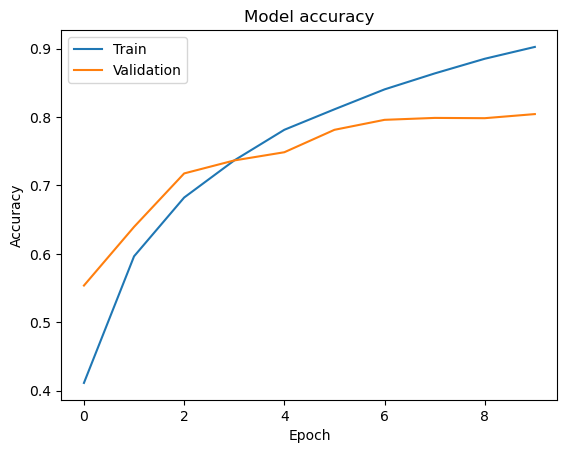

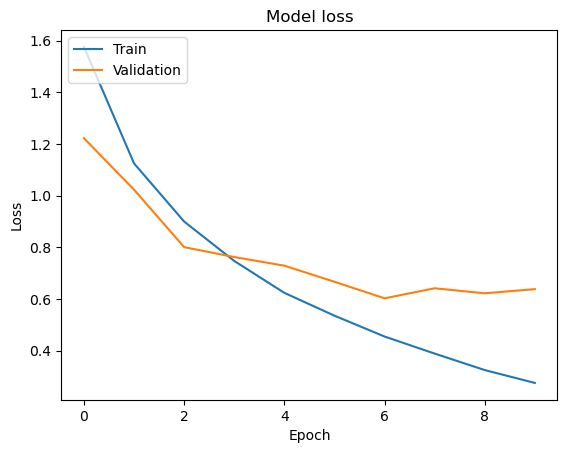

In [12]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


### Evaluate the Model

We evaluate the model's performance on a test dataset and computes the test accuracy by comparing its predictions to the true labels. The test accuracy reflects how well the model generalizes to new, unseen data.

In [13]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)


313/313 [==============================] - 28s 88ms/step - loss: 0.6367 - accuracy: 0.7822
Test accuracy: 0.7821999788284302


### Evaluation Metrics

We calculate `precision`, `recall`, and `F1-score` for the model's predictions on the test data. 

It first converts predicted probabilities to class labels and then computes these classification metrics. 


- The `precision` measures the accuracy of positive class predictions
- `Recall` assesses the ability to capture true positives
- `F1-score` provides a balance between precision and recall. 


The `macro` averaging is used to compute these metrics across all classes and is suitable for multi-class classification tasks.

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Assuming you have made predictions on the test data
y_pred = model.predict(x_test)

# Convert predicted probabilities to class labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Compute precision, recall, and F1-score
precision = precision_score(y_test, y_pred_labels, average='macro')
recall = recall_score(y_test, y_pred_labels, average='macro')
f1 = f1_score(y_test, y_pred_labels, average='macro')

print('Precision:', precision)
print('Recall:', recall)
print('F1-score:', f1)


313/313 [==============================] - 28s 87ms/step
Precision: 0.7915206339817622
Recall: 0.7821999999999999
F1-score: 0.7842986006934489


### Analyzing Results

We use `scikit-learn` to create a confusion matrix for the prediction on a test dataset and then visualize it using `seaborn`. 

The matrix is displayed as a heatmap with annotations. It also provides class labels for different categories such as 'T-shirt/top,' 'Trouser,' 'Pullover,' and others. 

313/313 [==============================] - 28s 90ms/step


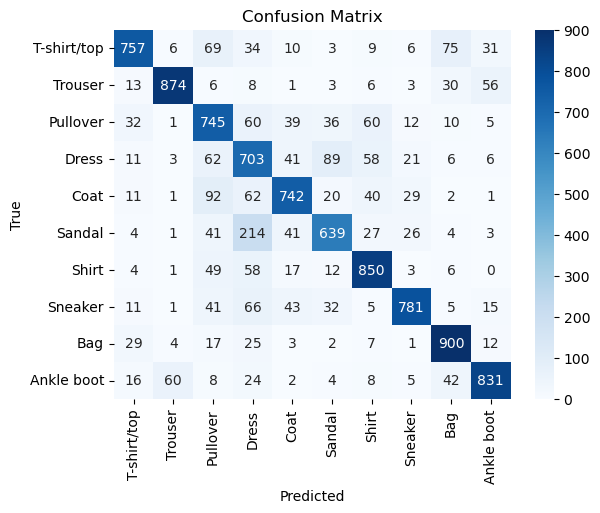

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


y_pred_valid = model.predict(x_test)
y_pred_valid = np.argmax(y_pred_valid, axis=1)
cm = confusion_matrix(y_test, y_pred_valid)


class_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')


plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


313/313 [==============================] - 28s 91ms/step


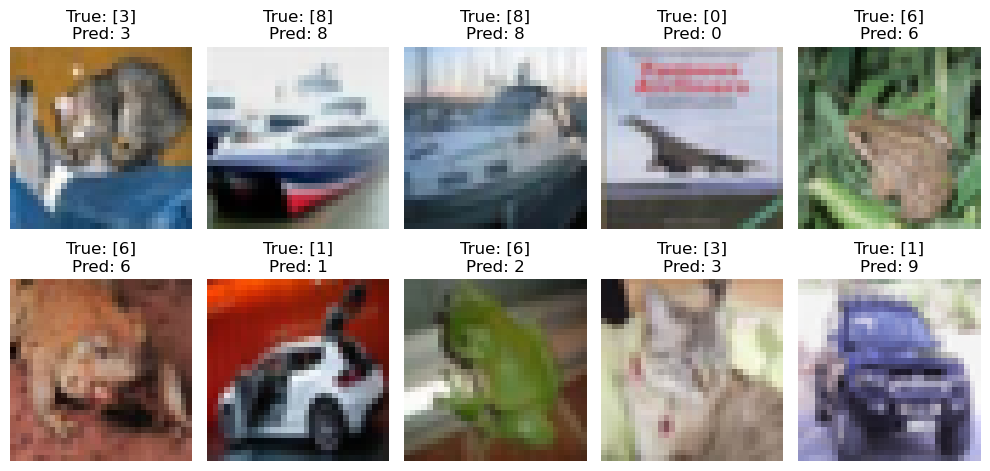

In [16]:
import matplotlib.pyplot as plt

# Get predictions for the test set
y_pred = model.predict(x_test)

# Create a figure with 2 rows and 5 columns
fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(10, 5))

# Plot images and their true/predicted labels
for i in range(2):
    for j in range(5):
        # Compute the index of the current image in the test set
        index = 5 * i + j
        
        # Plot the current image
        axs[i, j].imshow(x_test[index])
        axs[i, j].axis('off')
        
        # Get the true label of the current image
        true_label = y_test[index]
        
        # Get the predicted label of the current image
        predicted_label = y_pred[index].argmax()
        
        # Add the true and predicted labels to the plot
        axs[i, j].set_title(f'True: {true_label}\nPred: {predicted_label}')
        
# Adjust spacing between subplots
fig.tight_layout()
plt.show()


### Happy Coding